In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV


import yaml
#from sklearn import train_test_split

import sys

sys.path.append("../src")
import functions as fn


#import dataset
with open("../config.yaml") as file:
    config = yaml.safe_load(file)
config


{'input_data': {'file1': '../data/raw/diabetes_prediction_dataset.csv',
  'file3': None},
 'output_data': {'file1': None}}

In [3]:
df = pd.read_csv(config['input_data']['file1'], delimiter = ",")
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [91]:
##############################################################################
# Cleaning Dataset
##############################################################################

def clean_dataset(df):
    """
    Drops duuplicated rows: 3854 in total
    """
    df1 = df.copy()
    df1 = df1.drop_duplicates(keep = 'first')
    df1 = df1.reset_index(drop = True)

    return df1


In [ ]:
df = clean_dataset(df)
df.tail()

In [59]:
df.smoking_history.unique()
#
#relationship beween columns
#sns.pairplot(df, hue = 'diabetes')

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

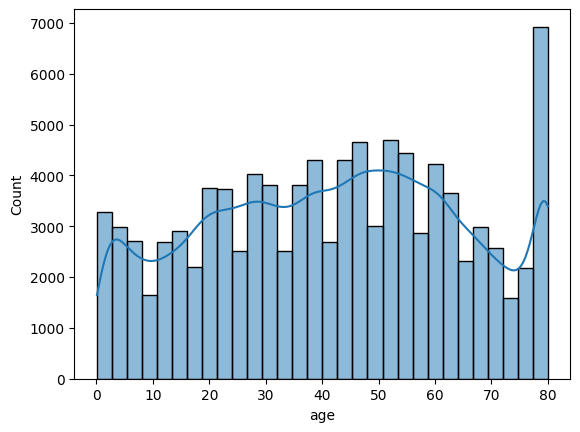

In [9]:
#Understand the sitribution of data
#Age distribution 
sns.histplot(data = df, x = 'age', bins = 30, kde = True)
plt.show()

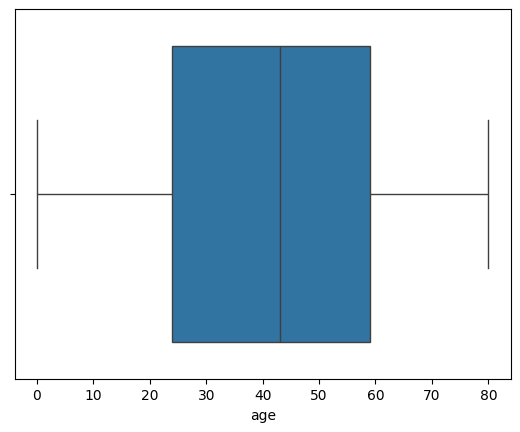

In [42]:
# Average age of patients


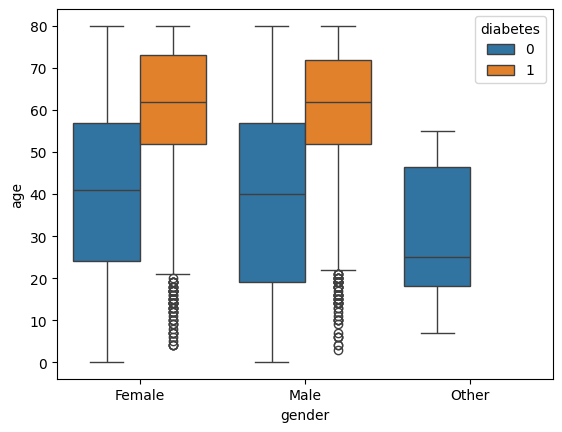

In [10]:
#AGE vs sex
sns.boxplot(data = df, x = 'gender', y = 'age', hue = 'diabetes')
plt.show()

# Dataset description:
Dataset is mainly cleaned, with redundant values. We dropped them to have consistent database. It consists of three columns categories:
### 1. Normalized data:
#### a. Already normalized:
Hypertension & heart_disease: both of them have binary values, 1 for "Yes", and 0 for "No". No further processing is needed.
#### b. Ordinal categorical columns:
smoking_history: ['never', 'No Info', 'current', 'former', 'ever', 'not current']. As there is no implicit order between them, we have chosen to consider them as nominal categorical data.
gender: femal, Male, Other: Ordinal categorical data 
#### c. Numerical:
age, bmi, HbA1c_level and blood_glucose_level: Ranges are quite big. Theses columns will be subject to scaling
# features Engineering:
## a. Encoding: OneHeadEncoding
OneHeadEncoding: used to encode the nominal categorical data "smoking_history"
## b. Normalization: 
Use MinMaxScaler() to normalize numerical data
# Predictive Model and Features engineering:
## a. KNN Model:
Our target data is clategorical, for this we have chosen KNN model

In [11]:
##############################################################################
# Dataset train_test_split
##############################################################################
def data_set_splitter(df):
    df1 = df.copy()
    features = df1.drop(columns = 'diabetes')
    target = df1['diabetes']
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size = 0.2, random_state = 40)
    return X_train, X_test, y_train, y_test
dX_train, X_test, y_train, y_test = data_set_splitter(df)
dX_train.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
46630,Male,20.0,0,0,current,24.50,5.7,145
94689,Female,16.0,0,0,never,34.52,4.8,126
63232,Male,63.0,0,0,No Info,27.32,6.5,100
56486,Male,22.0,0,0,not current,27.32,5.0,130
65811,Male,55.0,0,0,never,24.11,5.7,159


In [12]:
# Features dummification: Encoding gender & smoking_history columns
#df1 = clean_dataset(df)
def get_ohe_encoded_col(df):
    """
    Features dummification: Encoding gender & smoking_history columns
    """
    df1 = df.copy()
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
   
    X_train_cat = X_train.select_dtypes('object')
    X_test_cat = X_test.select_dtypes('object')
    #create a OneHotENcoder class instance
    ohe = OneHotEncoder(sparse_output = False, drop = 'first')
    #determine unique values of each column
    ohe.fit(X_train_cat)
    #ohe.fit(X_test_cat) # NOOO fit only train data
    #Output np array
    X_train_np = ohe.transform(X_train_cat)
    X_test_np = ohe.transform(X_test_cat)
    #tranfsorm the np aaray to df
    X_train_ohe_df = pd.DataFrame(X_train_np, columns = ohe.get_feature_names_out(), index = X_train_cat.index)
    X_test_ohe_df= pd.DataFrame(X_test_np, columns = ohe.get_feature_names_out(), index = X_test_cat.index)
    

    return X_train_ohe_df, X_test_ohe_df
    

X_train_ohe_df, X_test_ohe_df = get_ohe_encoded_col(df) #X_train_ohe_df, X_test_ohe_df, 

X_train_ohe_df.head()

,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
46630,1.0,0.0,1.0,0.0,0.0,0.0,0.0
94689,0.0,0.0,0.0,0.0,0.0,1.0,0.0
63232,1.0,0.0,0.0,0.0,0.0,0.0,0.0
56486,1.0,0.0,0.0,0.0,0.0,0.0,1.0
65811,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
# Scaling: Normalization of numerical data
#TO REDO SPLIT DATSET BEFORE NORMLIZATION
def get_normalized_col(df):

    df1 = df.copy()
    #train_test_split
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
    X_train_num = X_train[['age', 'bmi','HbA1c_level', 'blood_glucose_level']]
    X_test_num = X_test[['age', 'bmi','HbA1c_level', 'blood_glucose_level']]

    #Create the scaler
    normalizer = MinMaxScaler()
    #determine Mi max of every colum
    normalizer.fit(X_train_num)
    #normalizer.fit(X_test_num) #NOO

    #transform data to np array
    X_train_num_np = normalizer.transform(X_train_num)
    X_test_num_np = normalizer.transform(X_test_num)
    
    #transfor np arrays to df
    X_train_normalized = pd.DataFrame(
                                        X_train_num_np,
                                        columns = X_train_num.columns, 
                                        index = X_train_num.index
                                    )
    X_test_normalized = pd.DataFrame(
                                        X_test_num_np,
                                        columns = X_test_num.columns,
                                        index = X_test_num.index
                                    )
    return X_train_normalized, X_test_normalized #, y_train, y_test#, combined_norm_df
X_train_normalized, X_test_normalized =get_normalized_col(df)
X_train_normalized.head()

,age,bmi,HbA1c_level,blood_glucose_level
46630,0.249249,0.170050,0.400000,0.295455
94689,0.199199,0.287642,0.236364,0.209091
63232,0.787287,0.203145,0.545455,0.090909
56486,0.274274,0.203145,0.272727,0.227273
65811,0.687187,0.165474,0.400000,0.359091


In [16]:
# Get the non processed df
def get_non_process_df(df):
    
    df1 = df.copy()
    X_train, X_test, y_train, y_test = data_set_splitter(df1)
    
    X_train_others = X_train[['hypertension', 'heart_disease']]
    X_test_others = X_test[['hypertension', 'heart_disease']]

    return X_train_others, X_test_others #, y_train, y_test
     
X_train_others,  X_test_others =  get_non_process_df(df)


def return_combined_train_test_split_df(df):

    #call Xtrain and Xtest from corresponding functions
    X_train_others,  X_test_others =  get_non_process_df(df)
    #y_train_others,  y_test_others =  get_non_process_df(df)[2:4]
    
    X_train_normalized, X_test_normalized = get_normalized_col(df)
    #y_train_normalized, y_test_normalized = get_normalized_col(df)[2:4]
    
    X_train_ohe_df, X_test_ohe_df = get_ohe_encoded_col(df)
    #y_train_ohe_df, y_test_ohe_df = get_ohe_encoded_col(df)[2:4]
   
    #concatenate df
    X_train_final = pd.concat([X_train_ohe_df, X_train_normalized, X_train_others], axis = 1)
    X_test_final = pd.concat([X_test_ohe_df, X_test_normalized, X_test_others], axis = 1)
    #y_train_final = pd.concat([y_train_ohe_df, y_train_normalized, y_train_others], axis = 1)
    #y_test_final = pd.concat([y_test_ohe_df, y_test_normalized, y_test_others], axis = 1)

    return X_train_final, X_test_final

X_train_final, X_test_final = return_combined_train_test_split_df(df)
display(X_train_others.head())
display(X_train_final.head())

,hypertension,heart_disease
46630,0,0
94689,0,0
63232,0,0
56486,0,0
65811,0,0


,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease
46630,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.249249,0.170050,0.400000,0.295455,0,0
94689,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.199199,0.287642,0.236364,0.209091,0,0
63232,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.787287,0.203145,0.545455,0.090909,0,0
56486,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.274274,0.203145,0.272727,0.227273,0,0
65811,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.687187,0.165474,0.400000,0.359091,0,0


In [ ]:
df.head()
diabetes = df.diabetes.value_counts()
diabetes
diabetes.plot(kind = 'bar')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xlabel("Diabetes status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Cases")

plt.show()

# KNN Model Evaluation
## Without Optimization

In [36]:
##############################################################################
# Train the KNN model: without optimization
##############################################################################
import time
start = time.time()
X_train_final, X_test_final = return_combined_train_test_split_df(df)
y_train_final, y_test_final = data_set_splitter(df)[2:4]

print("Preprocessing:", time.time() - start)

start = time.time()
#Create class instance of KNN predective model
knn = KNeighborsClassifier(n_neighbors =10, n_jobs=-1)

#train the model
knn.fit(X_train_final, y_train_final)
print("Fit:", time.time() - start)

#Make predictions
start = time.time()

y_pred_test= knn.predict(X_test_final)
print("Predict:", time.time() - start)

#Evaluate model
start = time.time()
#print(f"Accuracy of the model on Train dataset is: {knn.score(X_train_final, y_train_final)*100: .2f}% ")
print(f"Accuracy of the model on Test dataset is: { knn.score(X_test_final, y_test_final)*100: .2f}%")
print("Score calculation:", time.time() - start)
#Classification reports
print("classification_report: ")
#print(classification_report(y_pred_test, y_test))
start = time.time()
class_report = classification_report(y_pred_test, y_test, output_dict = True)
class_report_df = pd.DataFrame(class_report).transpose()
class_report_df = class_report_df.iloc[0:2, :]
class_report_df
#print("Calisification report (Precision / Recall / F1-score):", time.time() - start)
#class_report

Preprocessing: 0.2709791660308838
Fit: 0.29414844512939453
Predict: 23.961605548858643
Accuracy of the model on Test dataset is:  96.16%
Score calculation: 23.487591981887817
classification_report: 


,precision,recall,f1-score,support
0,0.998416,0.961085,0.979395,19016.0
1,0.563422,0.970528,0.712953,984.0


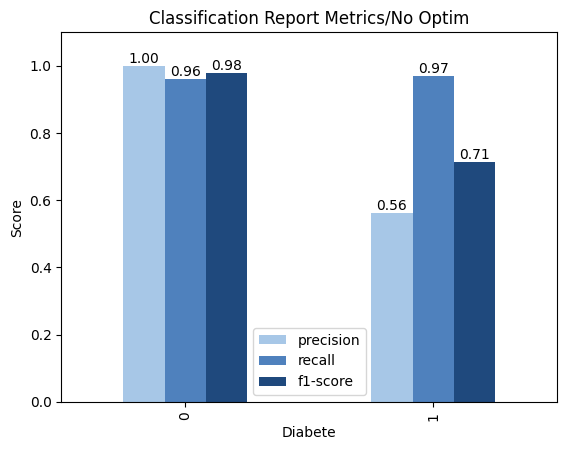

,precision,recall,f1-score
0,0.998416,0.961085,0.979395
1,0.563422,0.970528,0.712953


In [64]:
#Plot bar plot to compare performance
class_report_df = class_report_df[["precision", "recall", "f1-score"]]
blue_palette = ["#A7C7E7", "#4F81BD", "#1F497D"]
ax = class_report_df.plot(kind="bar", color=blue_palette)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.ylim(0, 1.1)  # Leave space for labels
plt.title("Classification Report Metrics/No Optim")
plt.xlabel("Diabete")
plt.ylabel("Score")

plt.show()
class_report_df

## Model Optimization
### Oversampling

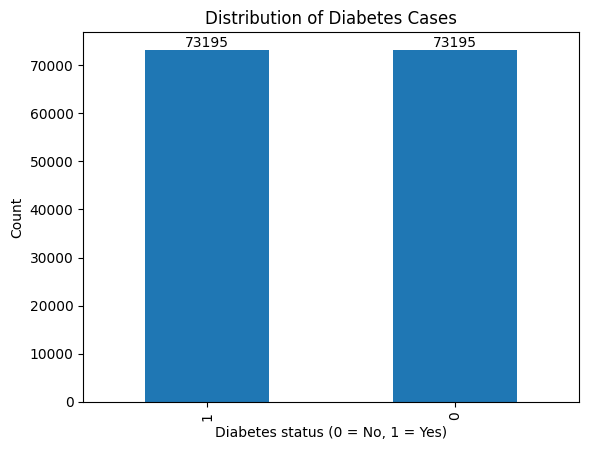

In [43]:
# Oversampling
X_train_final, X_test_final = return_combined_train_test_split_df(df)
y_train_final, y_test_final = data_set_splitter(df)[2:4]
train = X_train_final
train['Diabete'] = y_train.values
#calculate how many 1 and 0 in y_train
diabete = train[train['Diabete'] == 1]
no_diabete = train[train['Diabete'] == 0]

len(diabete), len(no_diabete)
#Increase the number of observations in the train dataset for diabete = 1
oversampled = resample(diabete,
                       replace = True,
                       n_samples = len(no_diabete),
                       random_state = 40
                      )
train_over_sampl = pd.concat([oversampled, no_diabete])
diabete_plt = train_over_sampl.Diabete.value_counts()
ax = diabete_plt.plot(kind = "bar")
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.xlabel("Diabetes status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Cases")
plt.show()
    

### Model Evaluation after Oversampling

In [67]:
#Create a new instance of KNN estimator after oversampling: Imbalance/oversampling
X_train_over = train_over_sampl.drop(columns = ['Diabete'])
y_train_over = train_over_sampl['Diabete']

#create instance of estimator
knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)

#train/fit estimator
knn.fit(X_train_over, y_train_over)

#Evaluate:

y_predict_test = knn.predict(X_test_final)
#Accuracy: 
calss_rep = calss_rep_imbal = pd.DataFrame(classification_report(y_predict_test, y_test, output_dict = True)).transpose()
calss_rep_imbal = pd.DataFrame(classification_report(y_predict_test, y_test, output_dict = True)).transpose().iloc[0:2, :]
calss_rep_imbal = calss_rep_imbal[["precision", "recall", "f1-score"]]
calss_rep

,precision,recall,f1-score,support
0,0.907457,0.983598,0.943995,16888.00000
1,0.836578,0.455656,0.589973,3112.00000
accuracy,0.901450,0.901450,0.901450,0.90145
macro avg,0.872018,0.719627,0.766984,20000.00000
weighted avg,0.896428,0.901450,0.888909,20000.00000


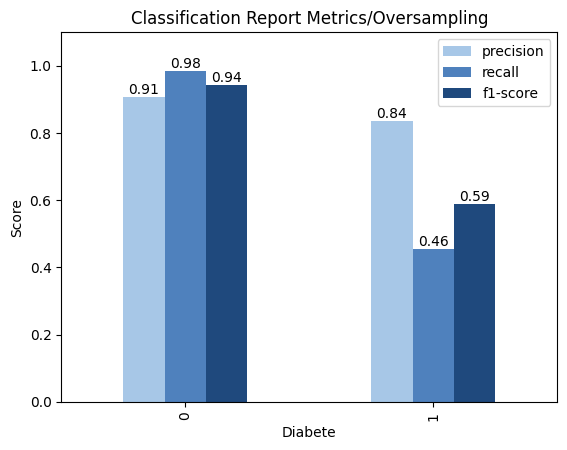

,precision,recall,f1-score
0,0.998416,0.961085,0.979395
1,0.563422,0.970528,0.712953


In [63]:
#Plot bar plot to compare performance: After Over sampling
calss_rep_imbal = calss_rep_imbal[["precision", "recall", "f1-score"]]
blue_palette = ["#A7C7E7", "#4F81BD", "#1F497D"]
ax1 = calss_rep_imbal.plot(kind="bar", color =blue_palette )

# Add labels on top of each bar
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f')

plt.ylim(0, 1.1)  # Leave space for labels
plt.title("Classification Report Metrics/Oversampling")
plt.ylabel("Score")
plt.xlabel("Diabete")
plt.show()
class_report_df

### Model Evaluation after optimization of Hyperparameters

In [68]:
# Select the best hyperparameter / Grid search:

# Define the best hyperparameter grid: with 'weights': ['uniform', 'distance'] it takes 960sec
param_grid = {
    'n_neighbors': [9, 11, 13]
}

# Run Grid Search
gs = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose = 10
)
#Train model
start_time = time.time()
gs.fit(X_train_over, y_train_over)
end_time = time.time()
print(f"Fitting model took: {end_time - start_time} seconds")

#################
# Best model from GridSearch
start_time = time.time()
best_knn = gs.best_estimator_
end_time = time.time()
# Predict
y_predict_test = best_knn.predict(X_test_final)
print(f"Find best estimator took: {end_time - start_time: .2f} seconds")

# Evaluate
optim_score = pd.DataFrame(classification_report(y_test, y_predict_test, output_dict = True)).transpose().iloc[0:2, :]
display(optim_score)
class_report2 = pd.DataFrame(classification_report(y_test, y_predict_test, output_dict = True)).transpose()
class_report2

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5; 1/3] START n_neighbors=9...............................................
[CV 1/5; 1/3] END ................n_neighbors=9;, score=0.948 total time=  20.8s
[CV 2/5; 1/3] START n_neighbors=9...............................................
[CV 2/5; 1/3] END ................n_neighbors=9;, score=0.943 total time=  21.5s
[CV 3/5; 1/3] START n_neighbors=9...............................................
[CV 3/5; 1/3] END ................n_neighbors=9;, score=0.945 total time=  21.6s
[CV 4/5; 1/3] START n_neighbors=9...............................................
[CV 4/5; 1/3] END ................n_neighbors=9;, score=0.943 total time=  20.4s
[CV 5/5; 1/3] START n_neighbors=9...............................................
[CV 5/5; 1/3] END ................n_neighbors=9;, score=0.947 total time=  21.6s
[CV 1/5; 2/3] START n_neighbors=11..............................................
[CV 1/5; 2/3] END ...............n_neighbors=11;,

,precision,recall,f1-score,support
0,0.983865,0.906091,0.943378,18305.0
1,0.452896,0.839528,0.588381,1695.0


,precision,recall,f1-score,support
0,0.983865,0.906091,0.943378,18305.00000
1,0.452896,0.839528,0.588381,1695.00000
accuracy,0.900450,0.900450,0.900450,0.90045
macro avg,0.718381,0.872810,0.765880,20000.00000
weighted avg,0.938866,0.900450,0.913292,20000.00000


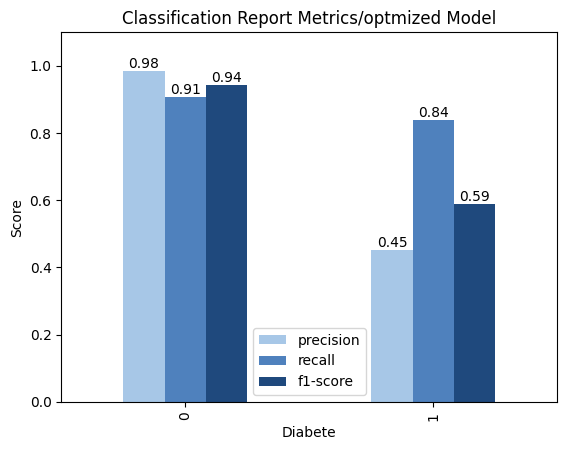

In [62]:
#Plot performance scores after optimization hyperparameters selection & oversampling
optim_score = optim_score[["precision", "recall", "f1-score"]]
blue_palette = ["#A7C7E7", "#4F81BD", "#1F497D"]
ax2 = optim_score.plot(kind="bar", color=blue_palette)

# Add labels on top of each bar
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f')

plt.ylim(0, 1.1)  # Leave space for labels
plt.title("Classification Report Metrics/optmized Model")
plt.ylabel("Score")
plt.xlabel("Diabete")

plt.show()

# Hypothesis Test: Association Between Hypertension and Diabetes
## Research Question
Is there a statistically significant association between hypertension status and diabetes status?
### Null Hypothesis (H₀)
Diabetes status is independent of hypertension status.

### Alternative Hypothesis (H₁)
Diabetes status is associated with hypertension status.

### Significance Level
α = 0.05

### Statistical Test
A Chi-square test of independence was performed to determine whether hypertension status and diabetes status are associated.


In [69]:
#Hypothesis testing
from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab( df['hypertension'], df['diabetes'] )
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print("Chi-square Statistic:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print(f"Reject the null hypothesis (p = {p_value:.4f} < {0.05}). "
          "There is statistically significant evidence of an association between hypertension and diabetes.")
else:
    print(f"Fail to reject the null hypothesis (p = {p_value:.4f} ≥ {0.05}). "
          "There is insufficient statistical evidence to conclude an association between hypertension and diabetes.")
# check the association strength: Cramer's V    
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dim))
print("Cramér's V:", cramers_v)

Chi-square Statistic: 3910.708546826595
p-value: 0.0
Reject the null hypothesis (p = 0.0000 < 0.05). There is statistically significant evidence of an association between hypertension and diabetes.
Cramér's V: 0.19775511489786035
